In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score
from sklearn.model_selection import train_test_split



In [6]:
df=sns.load_dataset('iris')

In [7]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [8]:
df.shape

(150, 5)

In [9]:
#basic data exploration
print("\nbasic information about Dataset:")
print(df.info())


basic information about Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [10]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [11]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.nunique()

sepal_length    35
sepal_width     23
petal_length    43
petal_width     22
species          3
dtype: int64

<Figure size 1200x800 with 0 Axes>

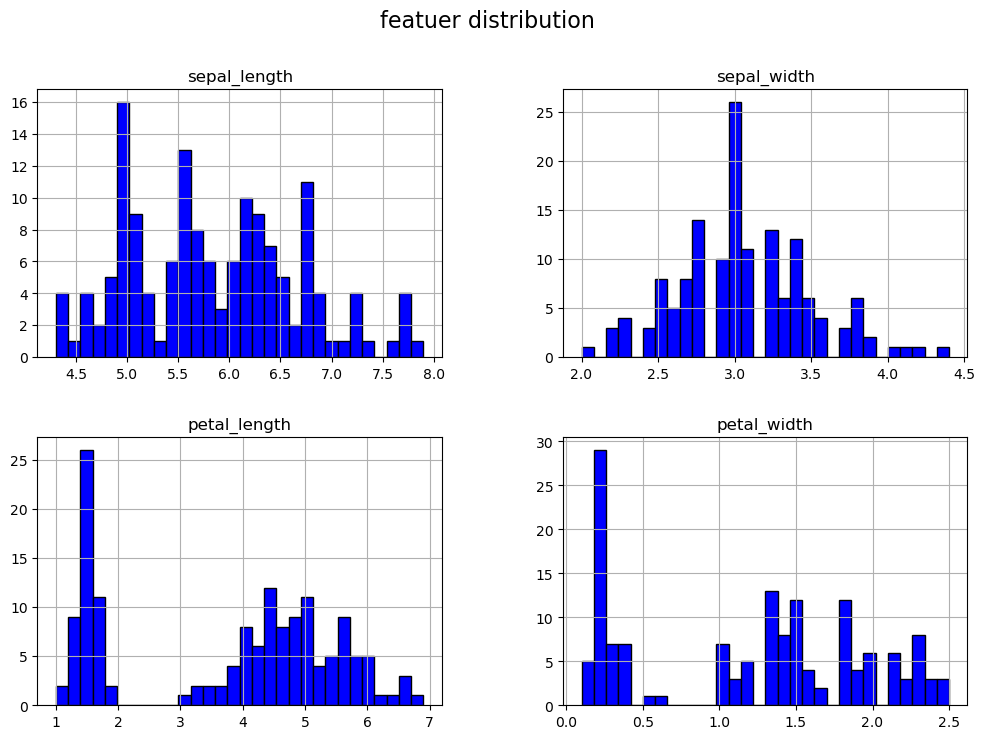

In [15]:
plt.figure(figsize=(12,8))
df.hist(figsize=(12,8),bins=30,color='b',edgecolor='black')
plt.suptitle("featuer distribution",fontsize=16)
plt.show()

#### <b><u> inferences from Histogram:</b></u>
1. **sepal length**:
   - the distribution of sepal length appears to be roughly normal with a slight skew towards the right.
   - most of the sepal lengths fall between 4.5 and 7.5cm
2. **sepal width**:
   - the distribution of sepal length appears to be roughly normal but with a slight skew towards the left.
   - most of the sepal lengths fall between 2.5 and 3.5cm
3. **petal length**":
    - the distribution of petal length is more spread
   out and shows a clear sepration between different species.
   - there are distinct peaks indicating the presence of different species with varying petal lengths.
        
4. **petal width**
  - similar to petal length, the distribution of petal width shows a clear sepration between different species.
   - there are distinct peaks indicating the presence of different species with varying petal width.

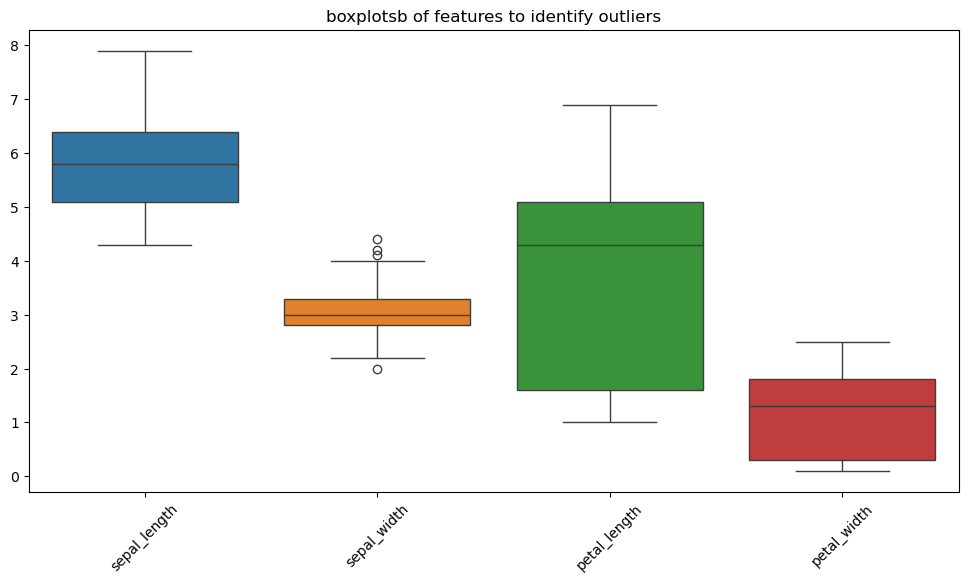

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("boxplotsb of features to identify outliers")
plt.show()

1. **sepal length**:
 - there are a few outliers in the sepal length distribution.
 - the median sepal length is around 5.8 cm,with the intrquatile range(IQR) between5.1 and 6.4 cm.

2. **sepal width**:
 - there are a few several outliers in the sepal width distribution.
 - the median sepal width is around 3.0cm,with the intrquatile range(IQR) between 2.1 and 3.3cm.

3. **petal length**
 - the petal length distribution shows clear sepration between species with minimal overlap
 - the median patel length varies significantly between species,indicating it is a good feature for classification

4. **patel width**
- similar to patel ,the petal width distribution shows clear sepration between species with minimal overlap
 - the median patel width varies significantly between species,indicating it is a good feature for classification

In [17]:
num_col=df.select_dtypes(include=[np.number]).columns
cat_col=df.select_dtypes(include=['object']).columns
print(f"numerical_data{num_col}")
print(f"categorical_data{cat_col}")

numerical_dataIndex(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')
categorical_dataIndex(['species'], dtype='object')


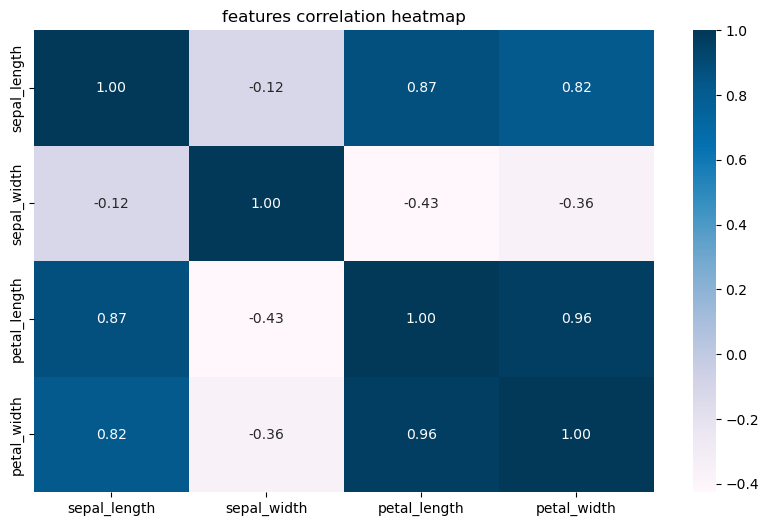

In [18]:
#correlation matrix
num=df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,6))
corr_matrix=df[num].corr('pearson')
sns.heatmap(corr_matrix,annot=True,cmap='PuBu',
            fmt='.2f')
plt.title("features correlation heatmap")
plt.show()

In [19]:
df.species.value_counts()

species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

In [20]:
label_encoder=LabelEncoder()
df["species"]=label_encoder.fit_transform(df["species"])

In [21]:
df.species.value_counts()

species
0    50
1    50
2    49
Name: count, dtype: int64

In [22]:
#define features and target
x=df.drop(columns=["species"])
y=df["species"]

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
x_train.shape

(119, 4)

In [25]:
x_test.shape

(30, 4)

In [26]:
def evaluate_knn(k_values,weights='uniform'):
    results={}
    for k in k_values:
        knn=KNeighborsClassifier(n_neighbors=k, 
                                 weights=weights)
        knn.fit(x_train,y_train)
        y_pred=knn.predict(x_test)
        accuracy=accuracy_score(y_test,y_pred)
        f1=f1_score(y_test,y_pred, 
                    average='weighted')
        results[k]={'accuracy':accuracy, 
                    'f1_score':f1}
    return results    

In [27]:
k_values=[3,5,7]
regular_knn_results=evaluate_knn(k_values, 
                                 weights='uniform')
weighted_knn_results=evaluate_knn(k_values,
                                  weights='distance')

In [28]:
print(regular_knn_results)
print(weighted_knn_results)

{3: {'accuracy': 1.0, 'f1_score': 1.0}, 5: {'accuracy': 1.0, 'f1_score': 1.0}, 7: {'accuracy': 1.0, 'f1_score': 1.0}}
{3: {'accuracy': 1.0, 'f1_score': 1.0}, 5: {'accuracy': 1.0, 'f1_score': 1.0}, 7: {'accuracy': 1.0, 'f1_score': 1.0}}
